## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/arvi/

Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)

Conversion: Development Seed (openEO-UDP project)

# Atmospherically Resistant Vegetation Index (ARVI)

This notebook demonstrates how to compute ARVI from Sentinel-2 imagery using the OpenEO platform. 

ARVI is a vegetation index designed to minimize the influence of atmospheric scattering -- such as haze, smoke, and aerosols -- on surface reflectance measurements. Unlike NDVI, which uses only the red and near-infrared bands, ARVI incorporates the blue band to self-correct for atmospheric effects. 

The blue band is used as a proxy for atmospheric scattering, since the atmosphere scatters shorter wavelengths more strongly. This correction is applied through a weighing factor `y = 0.106`, which was empirically derived for typical atmospheric conditions. ARVI is computed using the equation:

$$\text{ARVI} = \frac{\text{B8A} - \text{B04} - y \cdot (\text{B04} - \text{B02})}{\text{B8A} + \text{B04} - y \cdot (\text{B04} - \text{B02})}$$

Where:
- B8A (864.7 nm): Narrow NIR
- B04 (664.6 nm): Red
- B02 (492.4 nm): Blue

## Overview

In this notebook, we will:
1. Connect to the Copernicus Data Space Ecosystem (CDSE) OpenEO backend
2. Define an area of interest containing agricultural land, for example over the Čepić plain, Istria, Croatia
3. Load Sentinel-2 L2A imagery (bands B02, B04, B8A) for 10–12 May 2025
4. Compute ARVI
5. Download and visualize the output in both grayscale and false-color (YlGn) colormaps


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [13]:
import openeo
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Connect to CDSE OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [14]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates for Čepić plain, Istria, Croatia.

In [15]:
spatial_extent = {"west": 14.09, "east": 14.27, "south": 45.174, "north": 45.25}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [16]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2025-05-10", "2025-05-12"],
    bands=[
        "B02",
        "B04",
        "B8A",
    ],
)

s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

# Scale digital numbers to reflectance [0, 1]
s2cube = s2cube / 10000

In [17]:
atm_correction = 0.106

def calculate_arvi(data, atmospheric_correction):
    B02, B04, B8A = data[0], data[1], data[2]

    correction = atmospheric_correction * (B04 - B02)
    index = (B8A - B04 - correction) / (B8A + B04 - correction)

    return index

In [18]:
arvi_image = s2cube.apply_dimension(
    dimension="bands",
    process=lambda data: calculate_arvi(data, atm_correction)
)

arvi_image = arvi_image.linear_scale_range(input_min=-1, input_max=1, output_min=0, output_max=255)

In [19]:
arvi_image.download("arvi_image.png")

## Visualize the Result

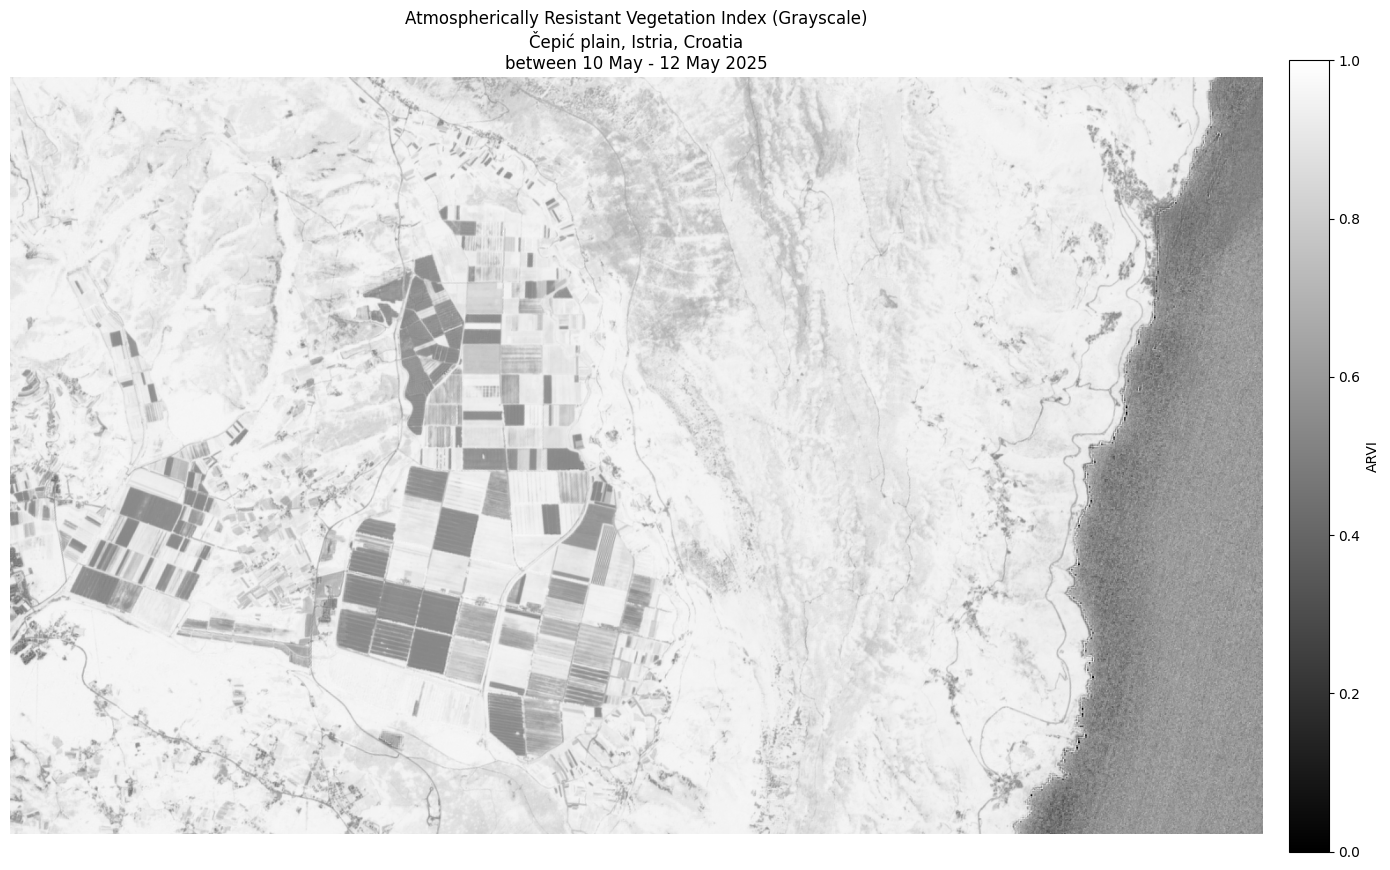

In [30]:
# Load and display the image
img = Image.open("arvi_image.png").convert("L")
arr = np.array(img) / 255.0

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
im = ax.imshow(arr, cmap="gray", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="ARVI", fraction=0.03, pad=0.02)
ax.set_title(
    "Atmospherically Resistant Vegetation Index (Grayscale)\n"
    "Čepić plain, Istria, Croatia\n"
    "between 10 May - 12 May 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

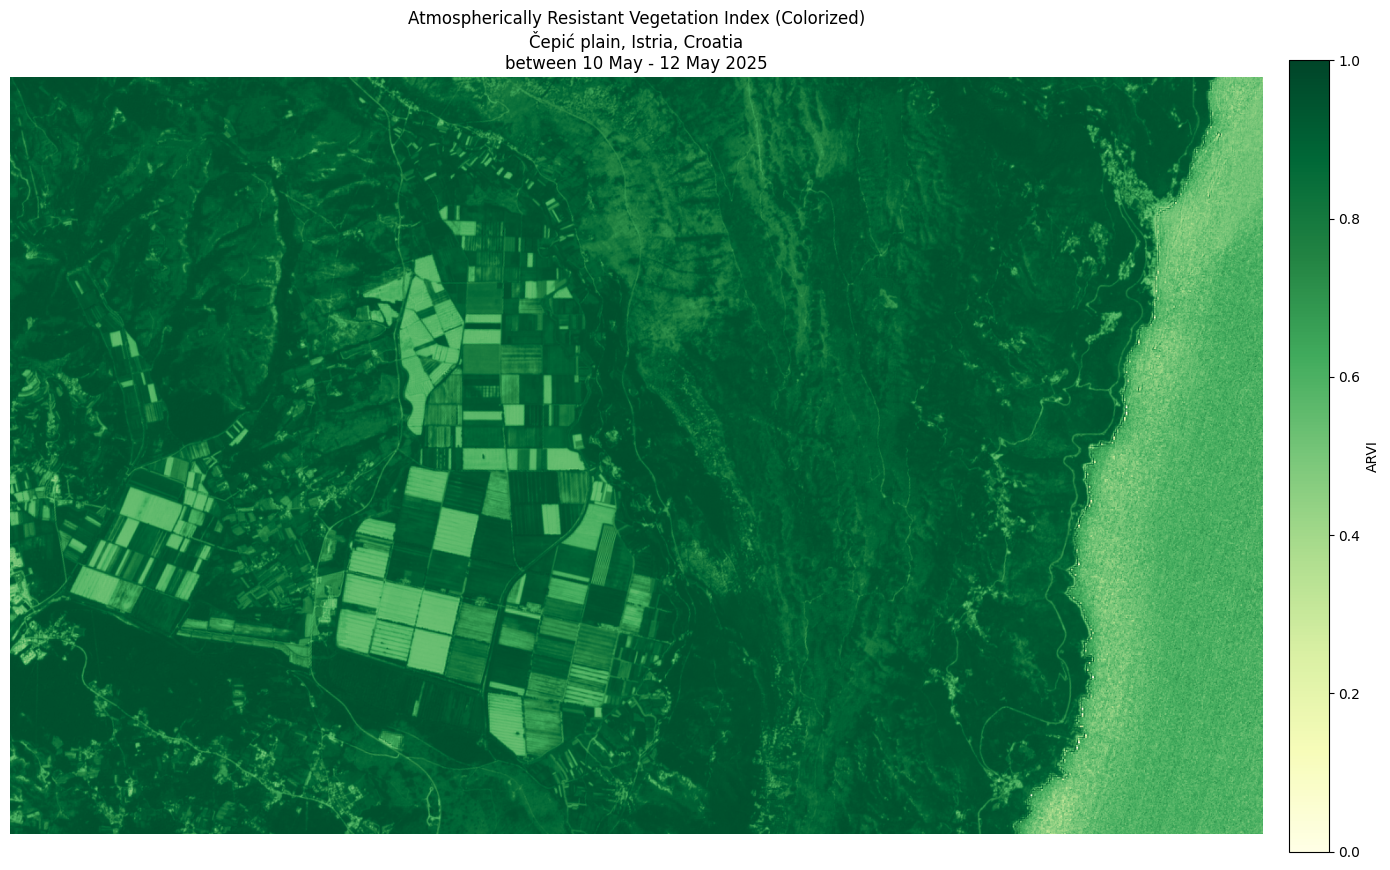

In [31]:
# Load and display the image
img = Image.open("arvi_image.png").convert("L")
arr = np.array(img) / 255.0

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
im = ax.imshow(arr, cmap="YlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="ARVI", fraction=0.03, pad=0.02)
ax.set_title(
    "Atmospherically Resistant Vegetation Index (Colorized)\n"
    "Čepić plain, Istria, Croatia\n"
    "between 10 May - 12 May 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation Guide

### ARVI Value Guide
| Color | Interpretation |
|-------|----------------------|
| Dark | ARVI close to -1, which shows low vegetation |
| Light | ARVI close to 1, which shows dense vegetation |

- Standard NDVI uses (NIR - RED) / (NIR + RED) — no atmospheric correction
- ARVI adds the blue band to compensate for atmospheric effects, making it more reliable over areas with smoke, haze, or high aerosol loads (e.g., tropical regions, fire-affected areas)

### Applications:
- Monitoring crop health and growth stages throughout agricultural season
- Detecting early signs of vegetation stress before they become visible to the naked eye
- Mapping vegetation density gradients across forests, grasslands, or wetlands
- Tracking seasonal and inter-annual changes in vegetation greenness

## Citation
The IDB Project. (2026). *Index: Atmospherically Resistant Vegetation Index (ARVI)*. IndexDatabase: https://www.indexdatabase.de/db/i-single.php?id=4

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Atmospherically Resistant Vegetation Index (ARVI)](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/arvi/)

**Author:** (Author is not listed in the original Evalscript)

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.